In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [2]:
# Standard library imports
import sys
from pathlib import Path

# Third-party scientific computing
import numpy as np
import pandas as pd

# Deep learning frameworks
import torch
import pytorch_lightning as pl

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer

# Local imports - models and evaluation
from src.models.TSMixer import LitTSMixer, TSMixerConfig
from src.models.evaluators import TSForecastEvaluator

# Append parent directory to path (if needed)
sys.path.append(str(Path().absolute().parent))

---

# Load the trained model

In [3]:
# Benchmark model configuration
BENCHMARK_INPUT_LENGTH: int = 256
BENCHMARK_OUTPUT_LENGTH: int = 10
BENCHMARK_HIDDEN_SIZE: int = 64
BENCHMARK_DROPOUT: float = 0.4
BENCHMARK_NUM_LAYERS: int = 2
BENCHMARK_STATIC_EMBEDDING_SIZE: int = 20
BENCHMARK_LEARNING_RATE: float = 0.00085

STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "snow_depth_water_equivalent_mean",
    "surface_net_solar_radiation_mean",
    "surface_net_thermal_radiation_mean",
    "potential_evaporation_sum_ERA5_LAND",
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "total_precipitation_sum",
]

TARGET = "streamflow"

ts_mixer_config = TSMixerConfig(
    input_len=BENCHMARK_INPUT_LENGTH,
    input_size=len(FORCING_FEATURES) + 1,  # +1 for target
    output_len=BENCHMARK_OUTPUT_LENGTH,
    static_size=len(STATIC_FEATURES) - 1,  # -1 for gauge_id
    hidden_size=BENCHMARK_HIDDEN_SIZE,
    static_embedding_size=BENCHMARK_STATIC_EMBEDDING_SIZE,
    num_layers=BENCHMARK_NUM_LAYERS,
    dropout=BENCHMARK_DROPOUT,
    learning_rate=BENCHMARK_LEARNING_RATE,
    group_identifier="gauge_id",
    lr_scheduler_patience=5,
    lr_scheduler_factor=0.5,
)

In [4]:
print("CONFIGURING CA DATASET (BASELINE)")
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()[:15]

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[
    ts_columns + ["date"] + ["gauge_id"]
]
ca_static_data = ca_caravan.get_static_attributes()[static_columns]

CONFIGURING CA DATASET (BASELINE)
Found 15 total CA basins


In [5]:
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline([("scaler", StandardScaleTransformer())]),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)

static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [6]:
STATIC_FEATURES = [col for col in static_columns if col != "gauge_id"]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=BENCHMARK_INPUT_LENGTH,
    output_length=BENCHMARK_OUTPUT_LENGTH,
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    min_train_years=8,
    val_years=2,
    test_years=3,
    max_missing_pct=10,
    domain_id="CA",
)

data_module.prepare_data()
data_module.setup()

Original basins: 15
Retained basins: 9
Domain CA (source): Created 53600 valid sequences from 9 catchments
Domain CA (source): Created 3621 valid sequences from 9 catchments
Domain CA (source): Created 7479 valid sequences from 9 catchments


In [7]:
data_module.static_features

['p_mean',
 'area',
 'ele_mt_sav',
 'high_prec_dur',
 'frac_snow',
 'high_prec_freq',
 'slp_dg_sav',
 'cly_pc_sav',
 'aridity_ERA5_LAND',
 'aridity_FAO_PM']

In [8]:
checkpoint_path = "/Users/cooper/Desktop/CAMELS-CH/experiments/Merged/saved_models/merged_dataset_benchmark/tsmixer_benchmark_0.ckpt"

model1 = LitTSMixer.load_from_checkpoint(checkpoint_path, config=ts_mixer_config)
model2 = LitTSMixer.load_from_checkpoint(checkpoint_path, config=ts_mixer_config)

In [9]:
evaluator = TSForecastEvaluator(
    datamodule=data_module,
    horizons=list(range(1, model1.config.output_len + 1)),
    models={
        "Model1": model1,
        "Model2": model2,
    },
    benchmark_model="Model1",
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
)

In [10]:
# Run evaluation
results = evaluator.test_models()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing Model1...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 15
Retained basins: 9
Domain CA (source): Created 7479 valid sequences from 9 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

...

Testing Model2...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 15
Retained basins: 9
Domain CA (source): Created 7479 valid sequences from 9 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

Predictions shape: torch.Size([7479, 10])
Observations shape: torch.Size([7479, 10])
Number of basin_ids: 7479
Number of input_end_dates: 7479
Configured horizons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Evaluating results with shape: preds=(7479, 10), obs=(7479, 10), basin_ids=(7479,)


In [11]:
evaluator.summarize_metrics(results["Model1"]["basin_metrics"], per_basin=True)

MSE       MAE       NSE      RMSE
basin_id horizon                                        
CA_15013 1        0.142039  0.226159  0.946401  0.376880
         2        0.232718  0.264913  0.912256  0.482408
         3        0.317105  0.311227  0.880539  0.563121
         4        0.392026  0.340111  0.852440  0.626120
         5        0.463532  0.375534  0.825678  0.680832
...                    ...       ...       ...       ...
CA_15069 6        0.030699  0.112734  0.960454  0.175211
         7        0.035641  0.124555  0.953908  0.188788
         8        0.041249  0.134050  0.946475  0.203098
         9        0.047857  0.145570  0.937692  0.218762
         10       0.056218  0.158133  0.926556  0.237104

[90 rows x 4 columns]

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '6-day Forecast for CA_15022'}, xlabel='Date', ylabel='Streamflow'>)

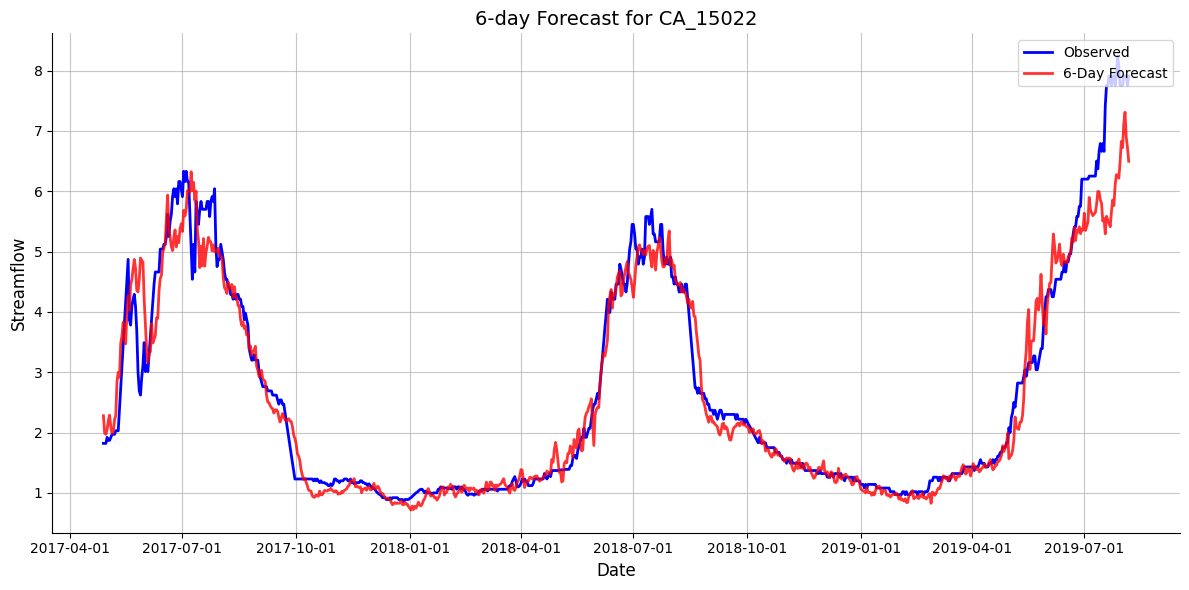

In [12]:
evaluator.plot_rolling_forecast(
    df=results["Model1"]["df"], 
    horizon=6, 
    group_identifier="CA_15022"
)

In [13]:
results["Model1"]["df"]

,horizon,prediction,observed,basin_id,date
0,1,1.741922,1.79,CA_15013,2020-09-13
1,2,1.653348,1.79,CA_15013,2020-09-14
2,3,1.650954,2.06,CA_15013,2020-09-15
3,4,1.642249,1.79,CA_15013,2020-09-16
4,5,1.654733,1.79,CA_15013,2020-09-17
...,...,...,...,...,...
74785,6,2.052742,2.04,CA_15069,2022-12-27
74786,7,2.075962,2.04,CA_15069,2022-12-28
74787,8,2.092496,2.04,CA_15069,2022-12-29
74788,9,2.097443,2.01,CA_15069,2022-12-30


In [14]:
results["Model2"].keys()

dict_keys(['df', 'metrics', 'basin_metrics'])

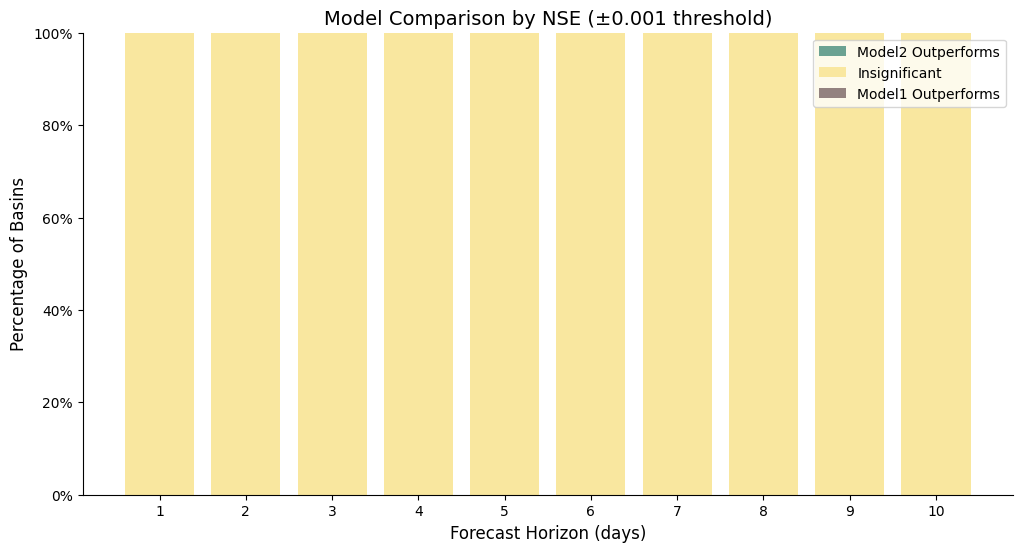

{'avg_better': np.float64(0.0), 'avg_insignificant': np.float64(100.0), 'avg_worse': np.float64(0.0), 'best_horizon': np.int64(1), 'best_horizon_pct': np.float64(0.0), 'worst_horizon': np.int64(1), 'worst_horizon_pct': np.float64(0.0)}


In [20]:
comparison_results = evaluator.compare_models("Model1", "Model2", metric="NSE", threshold=0.001)

# Plot the stacked bar chart of the comparison results
fig, ax = evaluator.plot_model_comparison(comparison_results)
plt.show()

# Optionally, print a summary of the comparison statistics
summary = evaluator.summarize_comparison(comparison_results)
print(summary)

In [16]:
# Pritn all available methods for the evaluator
print("Available methods for the evaluator:")
for method_name in dir(evaluator):
    if callable(getattr(evaluator, method_name)) and not method_name.startswith("__"):
        print(method_name)

Available methods for the evaluator:
_calculate_metrics
_calculate_performance_comparison
analyze_basin_performance
calculate_mae
calculate_mse
calculate_nse
calculate_rmse
compare_models
evaluate
flatten_basin_metrics
plot_model_comparison
plot_nse_comparison
plot_rolling_forecast
summarize_comparison
summarize_metrics
test_models


(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Model Performance Comparison by Horizon (NSE)'}, xlabel='Forecast Horizon (days)', ylabel='Average NSE'>)

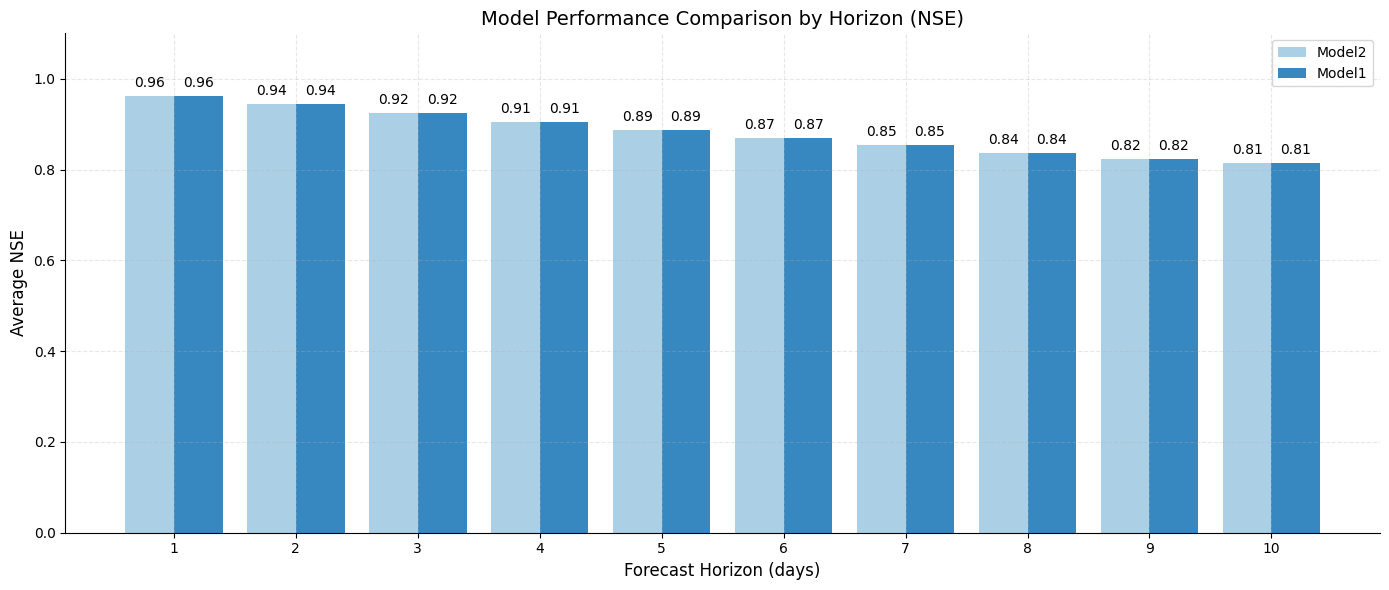

In [23]:
evaluator.plot_nse_comparison(
    "Model1",
    "Model2",
    metric="NSE",
)